In [ ]:
# Data handling
import pandas as pd
import numpy as np
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Dimensionality Reduction & Feature Analysis
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Interpretability (Optional, for model explanation)
import shap

# System & Warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dhoogla/cicmalmem2022")

print("Path to dataset files:", path)

100%|██████████| 3.31M/3.31M [00:01<00:00, 2.64MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/dhoogla/cicmalmem2022/versions/3


In [ ]:
# Use kagglehub to get the dataset path
import kagglehub
path = kagglehub.dataset_download("dhoogla/cicmalmem2022")
print(" Dataset files downloaded to:", path)

# List available files
print("\nFiles in dataset folder:")
print(os.listdir(path))

# Load the Parquet file
file_path = os.path.join(path, "Obfuscated-MalMem2022.parquet")
df = pd.read_parquet(file_path)

 Dataset files downloaded to: /kaggle/input/cicmalmem2022

Files in dataset folder:
['Obfuscated-MalMem2022.parquet']


In [ ]:
# =======================
#  GENERAL DATA OVERVIEW
# =======================

# 1. Dataset shape and preview
print("\n Dataset shape:", df.shape)
print("\n First 5 rows:")
display(df.head())

# 2. Data types and memory info
print("\n Dataset info:")
df.info()

# 3. Descriptive statistics
print("\n Descriptive statistics:")
display(df.describe())

# 4. Missing values
print("\n Missing values per column:")
display(df.isnull().sum())

# 5. Duplicated rows
print("\n Number of duplicated rows:", df.duplicated().sum())


 Dataset shape: (58058, 57)

 First 5 rows:


,Category,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.nprocs64bit,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,...,svcscan.kernel_drivers,svcscan.fs_drivers,svcscan.process_services,svcscan.shared_process_services,svcscan.interactive_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.nanonymous,callbacks.ngeneric,Class
0,Benign,45,17,10.555555,0,202.844452,1694,38.500000,9129,212.302322,...,221,26,24,116,0,121,87,0,8,Benign
1,Benign,47,19,11.531915,0,242.234039,2074,44.127659,11385,242.234039,...,222,26,24,118,0,122,87,0,8,Benign
2,Benign,40,14,14.725000,0,288.225006,1932,48.299999,11529,288.225006,...,222,26,27,118,0,120,88,0,8,Benign
3,Benign,32,13,13.500000,0,264.281250,1445,45.156250,8457,264.281250,...,222,26,27,118,0,120,88,0,8,Benign
4,Benign,42,16,11.452381,0,281.333344,2067,49.214287,11816,281.333344,...,222,26,24,118,0,124,87,0,8,Benign



 Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58058 entries, 0 to 58057
Data columns (total 57 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Category                                58058 non-null  object 
 1   pslist.nproc                            58058 non-null  int16  
 2   pslist.nppid                            58058 non-null  int8   
 3   pslist.avg_threads                      58058 non-null  float32
 4   pslist.nprocs64bit                      58058 non-null  int8   
 5   pslist.avg_handlers                     58058 non-null  float32
 6   dlllist.ndlls                           58058 non-null  int16  
 7   dlllist.avg_dlls_per_proc               58058 non-null  float32
 8   handles.nhandles                        58058 non-null  int32  
 9   handles.avg_handles_per_proc            58058 non-null  float32
 10  handles.nport                           58

,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.nprocs64bit,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,handles.nport,...,svcscan.nservices,svcscan.kernel_drivers,svcscan.fs_drivers,svcscan.process_services,svcscan.shared_process_services,svcscan.interactive_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.nanonymous,callbacks.ngeneric
count,58058.000000,58058.000000,58058.000000,58058.0,58058.000000,58058.000000,58058.000000,5.805800e+04,58058.000000,58058.0,...,58058.000000,58058.000000,58058.000000,58058.00000,58058.000000,58058.0,58058.000000,58058.000000,58058.000000,58058.000000
mean,41.407455,14.709549,11.350468,0.0,247.800217,1812.943315,43.744797,1.027403e+04,249.851257,0.0,...,391.366788,221.410038,25.996211,25.07136,116.887371,0.0,122.011299,86.912915,0.000861,7.999879
std,5.778080,2.661240,1.587734,0.0,112.288681,329.860993,5.738330,4.884754e+03,146.613251,0.0,...,4.538973,1.999357,0.171579,1.53100,1.551258,0.0,2.819536,3.115413,0.029334,0.010980
min,21.000000,8.000000,1.650000,0.0,34.962502,670.000000,7.333333,3.514000e+03,71.139244,0.0,...,94.000000,55.000000,6.000000,7.00000,26.000000,0.0,30.000000,50.000000,0.000000,7.000000
25%,40.000000,12.000000,9.973684,0.0,208.774994,1556.000000,38.849998,8.402000e+03,209.743740,0.0,...,389.000000,221.000000,26.000000,24.00000,116.000000,0.0,121.000000,87.000000,0.000000,8.000000
50%,41.000000,15.000000,11.022727,0.0,244.778084,1739.000000,42.974648,9.437000e+03,248.304367,0.0,...,392.000000,222.000000,26.000000,24.00000,118.000000,0.0,122.000000,87.000000,0.000000,8.000000
75%,43.000000,16.000000,12.867817,0.0,290.087318,2088.000000,49.625000,1.219600e+04,291.438698,0.0,...,395.000000,222.000000,26.000000,27.00000,118.000000,0.0,123.000000,88.000000,0.000000,8.000000
max,240.000000,72.000000,16.818182,0.0,24845.951172,3443.000000,53.170731,1.047310e+06,33784.195312,0.0,...,395.000000,222.000000,26.000000,27.00000,118.000000,0.0,129.000000,89.000000,1.000000,8.000000



 Missing values per column:


,0
Category,0
pslist.nproc,0
pslist.nppid,0
pslist.avg_threads,0
pslist.nprocs64bit,0
pslist.avg_handlers,0
dlllist.ndlls,0
dlllist.avg_dlls_per_proc,0
handles.nhandles,0
handles.avg_handles_per_proc,0



 Number of duplicated rows: 0



 Class distribution:
Class
Benign     29227
Malware    28831
Name: count, dtype: int64


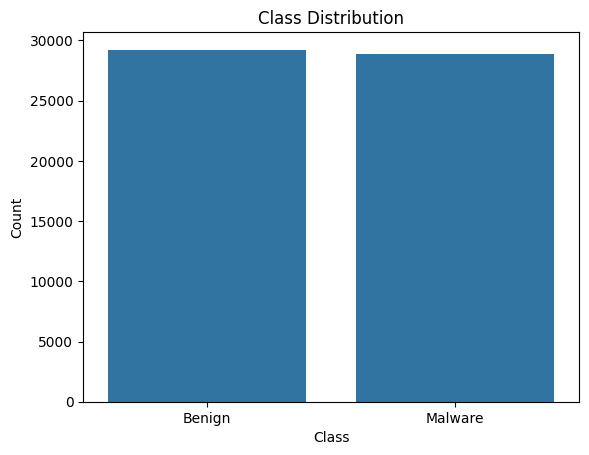

In [ ]:
# 6. Target/class distribution
target_col = 'Class'
if target_col in df.columns:
    print("\n Class distribution:")
    print(df[target_col].value_counts())

    # Plot class distribution
    sns.countplot(x=target_col, data=df)
    plt.title("Class Distribution")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.show()

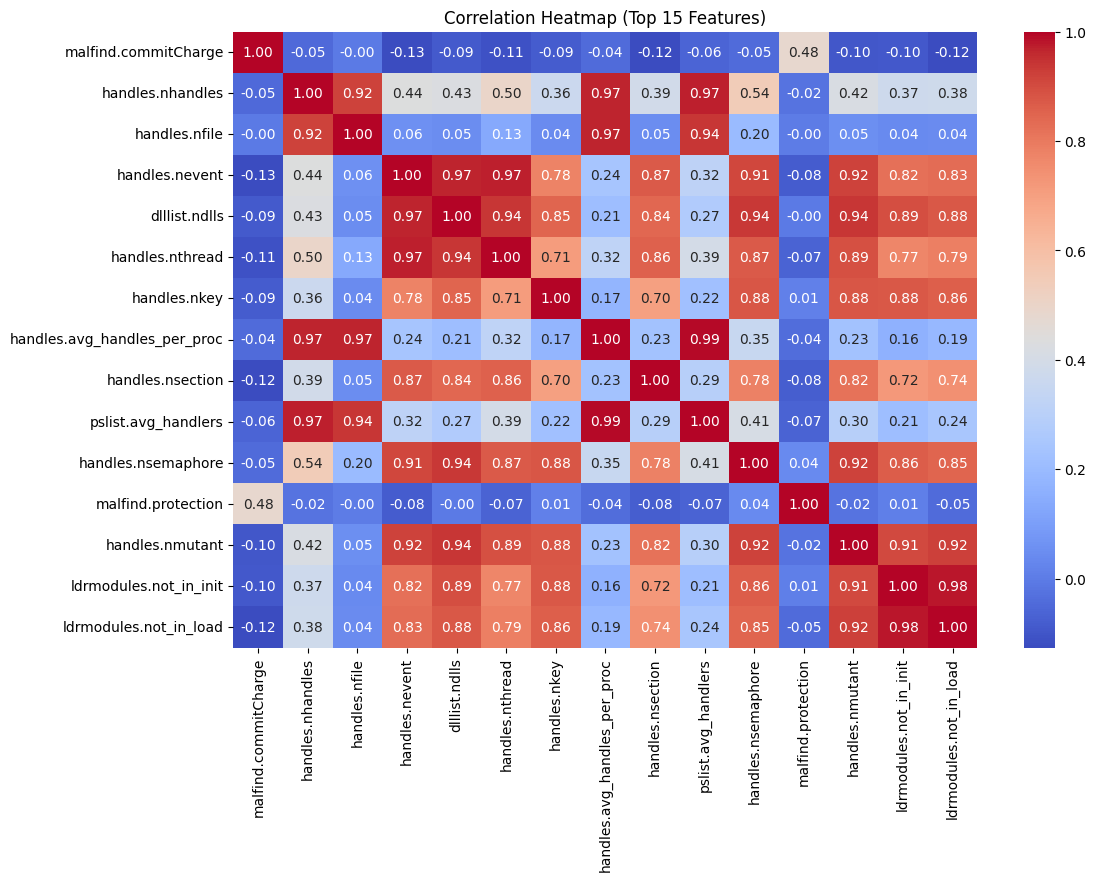

In [ ]:
# 7. Correlation heatmap (top 15 by variance)
numeric_df = df.select_dtypes(include=[np.number])
top_vars = numeric_df.var().sort_values(ascending=False).head(15).index
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df[top_vars].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Top 15 Features)")
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

# Ensure target is binary
if df['Class'].dtype == 'object':
    df['Class'] = df['Class'].map({'Benign': 0, 'Malware': 1})

X = df.drop(columns=['Class', 'Category'])  # Drop non-numeric & target
y = df['Class']

print(" Checking single-feature AUROC scores (depth=1)...\n")

suspicious_features = []

for col in tqdm(X.columns):
    model = DecisionTreeClassifier(max_depth=1, random_state=42)
    model.fit(X[[col]], y)
    probs = model.predict_proba(X[[col]])[:, 1]
    auc = roc_auc_score(y, probs)

    if auc > 0.98:
        suspicious_features.append((col, auc))
        print(f" {col}: AUROC = {auc:.4f}")

# Show all suspicious features (if any)
if suspicious_features:
    print("\n Features with suspiciously high AUROC:")
    for f, a in sorted(suspicious_features, key=lambda x: -x[1]):
        print(f"{f:<40} AUROC: {a:.4f}")
else:
    print(" No features with AUROC > 0.98 found.")

 Checking single-feature AUROC scores (depth=1)...



  7%|▋         | 4/55 [00:00<00:01, 37.53it/s]

 pslist.avg_handlers: AUROC = 0.9846
 dlllist.avg_dlls_per_proc: AUROC = 0.9873


 22%|██▏       | 12/55 [00:00<00:01, 37.44it/s]

 handles.nhandles: AUROC = 0.9812
 handles.avg_handles_per_proc: AUROC = 0.9851
 handles.nevent: AUROC = 0.9847


 60%|██████    | 33/55 [00:00<00:00, 61.11it/s]

 handles.nsection: AUROC = 0.9853
 handles.nmutant: AUROC = 0.9876


100%|██████████| 55/55 [00:00<00:00, 61.28it/s]

 svcscan.nservices: AUROC = 0.9966
 svcscan.kernel_drivers: AUROC = 0.9957
 svcscan.shared_process_services: AUROC = 0.9963

 Features with suspiciously high AUROC:
svcscan.nservices                        AUROC: 0.9966
svcscan.shared_process_services          AUROC: 0.9963
svcscan.kernel_drivers                   AUROC: 0.9957
handles.nmutant                          AUROC: 0.9876
dlllist.avg_dlls_per_proc                AUROC: 0.9873
handles.nsection                         AUROC: 0.9853
handles.avg_handles_per_proc             AUROC: 0.9851
handles.nevent                           AUROC: 0.9847
pslist.avg_handlers                      AUROC: 0.9846
handles.nhandles                         AUROC: 0.9812


In [ ]:
# Define leaky features (already identified by AUROC > 0.98)
leaky_features = [
    'svcscan.nservices',
    'svcscan.shared_process_services',
    'svcscan.kernel_drivers',
    'handles.nmutant',
    'dlllist.avg_dlls_per_proc',
    'handles.nsection',
    'handles.avg_handles_per_proc',
    'handles.nevent',
    'pslist.avg_handlers',
    'handles.nhandles',
]

# Remove them from the feature set
X_clean = X.drop(columns=leaky_features)

print(" Cleaned feature matrix shape:", X_clean.shape)

 Cleaned feature matrix shape: (58058, 45)


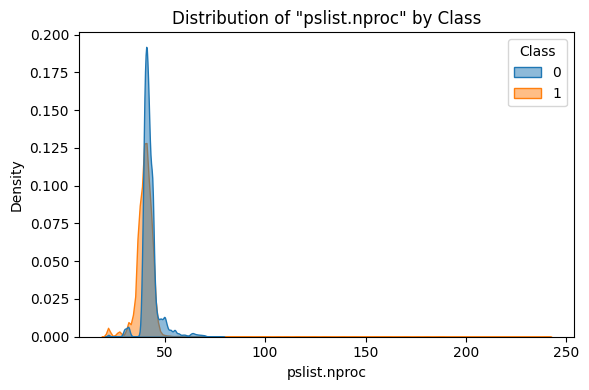

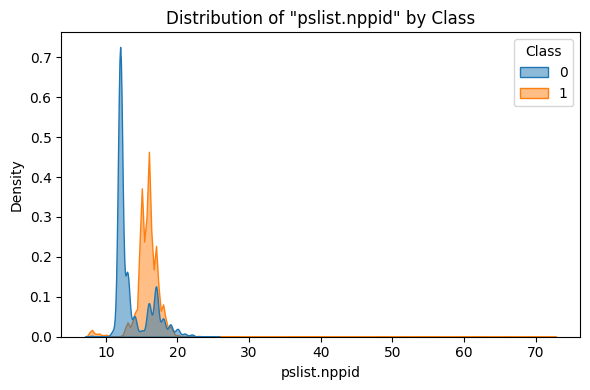

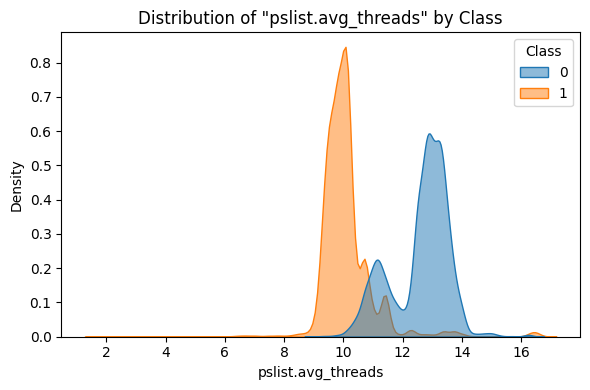

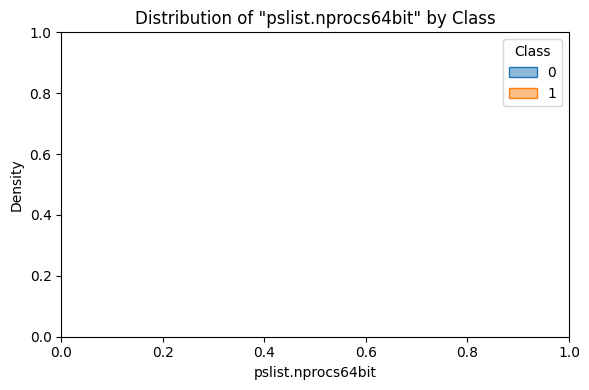

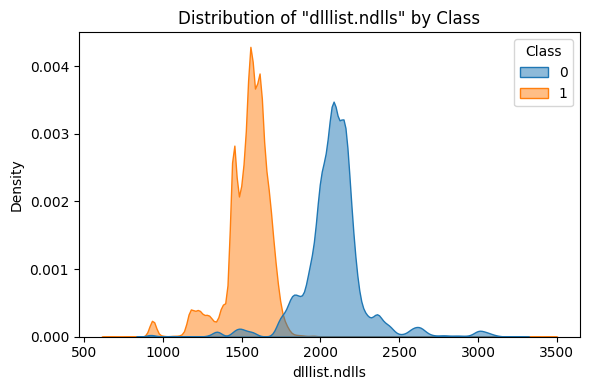

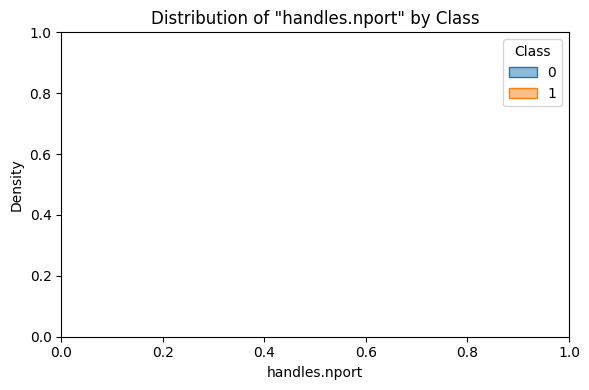

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sample a few cleaned features for distribution plot
sample_features = X_clean.columns[:6]  # pick first 6, or select manually

for feature in sample_features:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(data=df, x=feature, hue='Class', fill=True, common_norm=False, alpha=0.5)
    plt.title(f'Distribution of "{feature}" by Class')
    plt.tight_layout()
    plt.show()

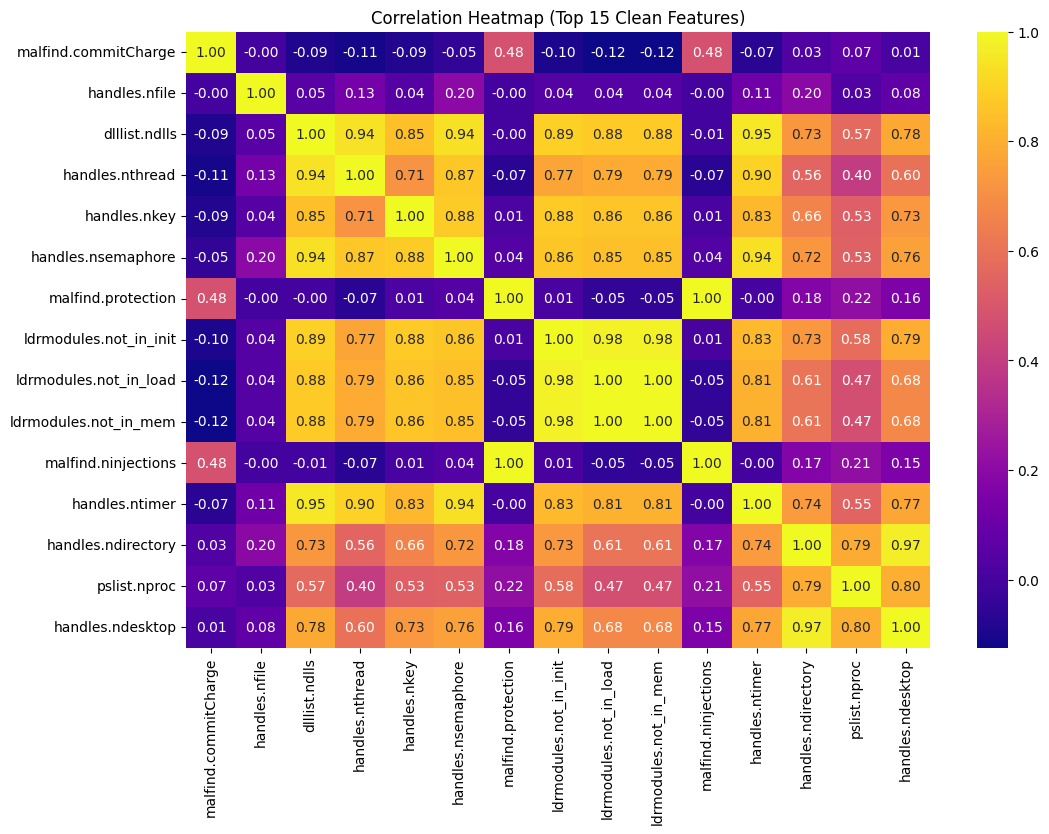

In [ ]:
# Only top 15 features by variance for readability
top_vars = X_clean.var().sort_values(ascending=False).head(15).index

plt.figure(figsize=(12, 8))
sns.heatmap(X_clean[top_vars].corr(), annot=True, cmap='plasma', fmt=".2f")
plt.title("Correlation Heatmap (Top 15 Clean Features)")
plt.show()

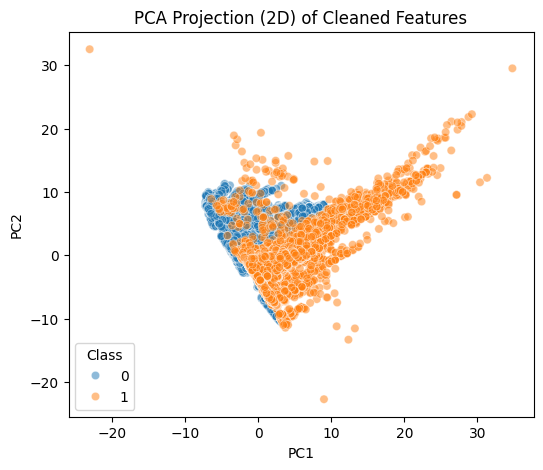

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['Class'], alpha=0.5)
plt.title("PCA Projection (2D) of Cleaned Features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Class")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# Target already cleaned and mapped: 0 = Benign, 1 = Malware
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, df['Class'], test_size=0.2, stratify=df['Class'], random_state=42
)

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(y_true, y_pred, y_prob, model_name="Model"):
    """
    Evaluate a classification model.

    Parameters:
    - y_true: true labels
    - y_pred: predicted labels
    - y_prob: predicted probabilities (for ROC AUC)
    - model_name: name to display in plots/reports
    """

    print(f"Evaluation Report for: {model_name}")
    print("-" * 40)

    # 1. Classification Report
    print("Classification Report:")
    print(classification_report(y_true, y_pred))

    # 2. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Benign", "Malware"],
                yticklabels=["Benign", "Malware"])
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    # 3. ROC Curve and AUC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_score = roc_auc_score(y_true, y_prob)

    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_score:.4f})")
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.title(f"{model_name} - ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"ROC AUC Score: {auc_score:.4f}")

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# Evaluate
print(" Random Forest Results:")
print(classification_report(y_test, rf_preds))
print("ROC-AUC:", roc_auc_score(y_test, rf_probs))

 Random Forest Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5846
           1       1.00      1.00      1.00      5766

    accuracy                           1.00     11612
   macro avg       1.00      1.00      1.00     11612
weighted avg       1.00      1.00      1.00     11612

ROC-AUC: 1.0


In [ ]:
# !pip install xgboost --quiet

from xgboost import XGBClassifier

# Train XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

# Predict
xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate
print("XGBoost Results:")
print(classification_report(y_test, xgb_preds))
print("ROC-AUC:", roc_auc_score(y_test, xgb_probs))

XGBoost Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5846
           1       1.00      1.00      1.00      5766

    accuracy                           1.00     11612
   macro avg       1.00      1.00      1.00     11612
weighted avg       1.00      1.00      1.00     11612

ROC-AUC: 1.0


Evaluation Report for: Random Forest
----------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5846
           1       1.00      1.00      1.00      5766

    accuracy                           1.00     11612
   macro avg       1.00      1.00      1.00     11612
weighted avg       1.00      1.00      1.00     11612



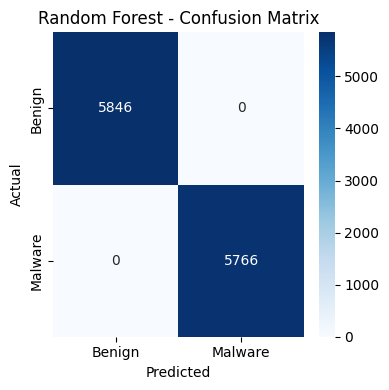

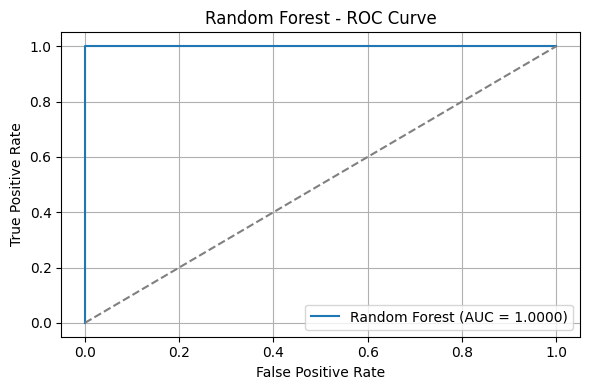

ROC AUC Score: 1.0000


In [ ]:
# Random Forest Evaluation
evaluate_model(y_test, rf_preds, rf_probs, model_name="Random Forest")

Evaluation Report for: XGBoost
----------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5846
           1       1.00      1.00      1.00      5766

    accuracy                           1.00     11612
   macro avg       1.00      1.00      1.00     11612
weighted avg       1.00      1.00      1.00     11612



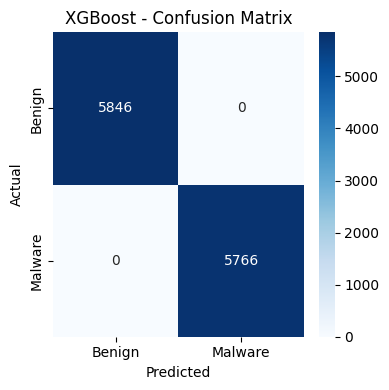

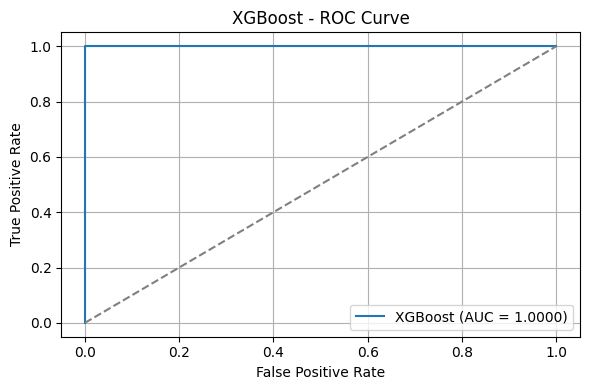

ROC AUC Score: 1.0000


In [ ]:
# XGBoost Evaluation
evaluate_model(y_test, xgb_preds, xgb_probs, model_name="XGBoost")

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Parameter Grid
param_dist_fast = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

# Base RF model
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# 2-fold stratified CV
cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

# Faster randomized search
rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_fast,
    n_iter=5,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit search
rf_search.fit(X_train, y_train)

# Best model and parameters
best_rf = rf_search.best_estimator_
print("Best Parameters (Fast Search):", rf_search.best_params_)

Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best Parameters (Fast Search): {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10}


Evaluation Report for: Random Forest (Tuned)
----------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5846
           1       1.00      1.00      1.00      5766

    accuracy                           1.00     11612
   macro avg       1.00      1.00      1.00     11612
weighted avg       1.00      1.00      1.00     11612



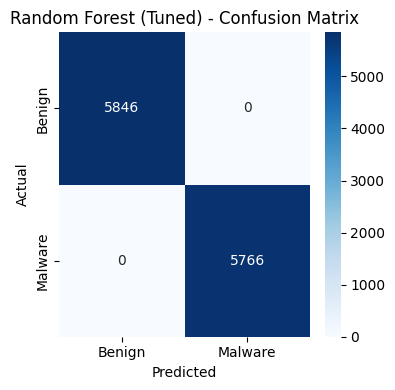

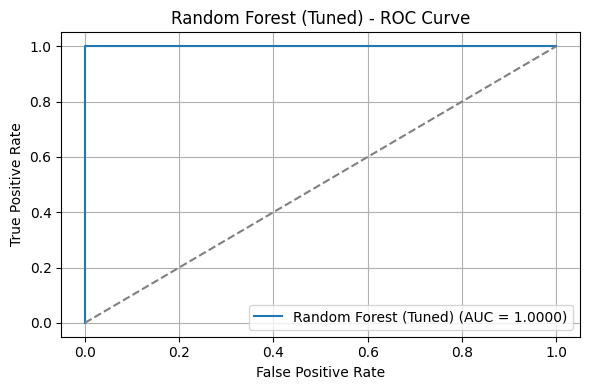

ROC AUC Score: 1.0000


In [ ]:
# Predict
rf_best_preds = best_rf.predict(X_test)
rf_best_probs = best_rf.predict_proba(X_test)[:, 1]

# Evaluate
evaluate_model(y_test, rf_best_preds, rf_best_probs, model_name="Random Forest (Tuned)")

In [ ]:
def compare_models(models, X_test, y_test):
    """
    Compare multiple models side-by-side with ROC AUC, classification report, and confusion matrix.
    Args:
        models: list of tuples (name, model, predictions, probabilities)
    """
    plt.figure(figsize=(7, 5))

    for name, y_pred, y_prob in models:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")
        print(f"\n{name} Report:")
        print(classification_report(y_test, y_pred))
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'{name} - Confusion Matrix')
        plt.xlabel('Predicted'); plt.ylabel('Actual')
        plt.show()

    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.title("ROC Curve Comparison")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Random Forest (Untuned) Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5846
           1       1.00      1.00      1.00      5766

    accuracy                           1.00     11612
   macro avg       1.00      1.00      1.00     11612
weighted avg       1.00      1.00      1.00     11612



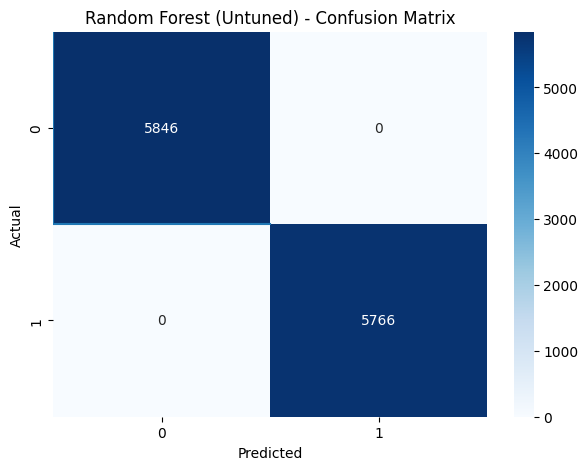


Random Forest (Tuned) Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5846
           1       1.00      1.00      1.00      5766

    accuracy                           1.00     11612
   macro avg       1.00      1.00      1.00     11612
weighted avg       1.00      1.00      1.00     11612



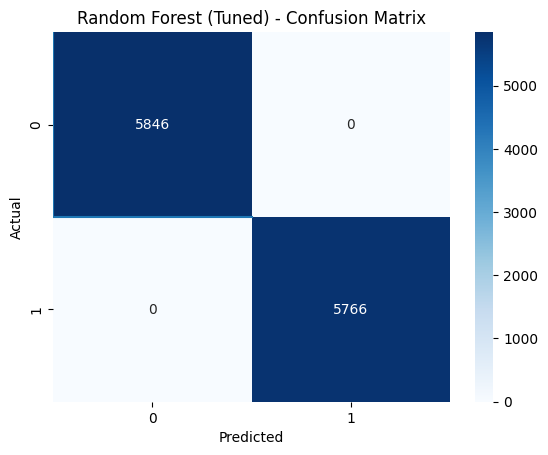


XGBoost Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5846
           1       1.00      1.00      1.00      5766

    accuracy                           1.00     11612
   macro avg       1.00      1.00      1.00     11612
weighted avg       1.00      1.00      1.00     11612



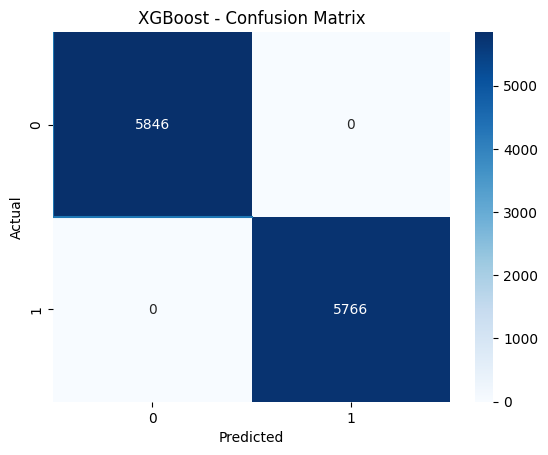

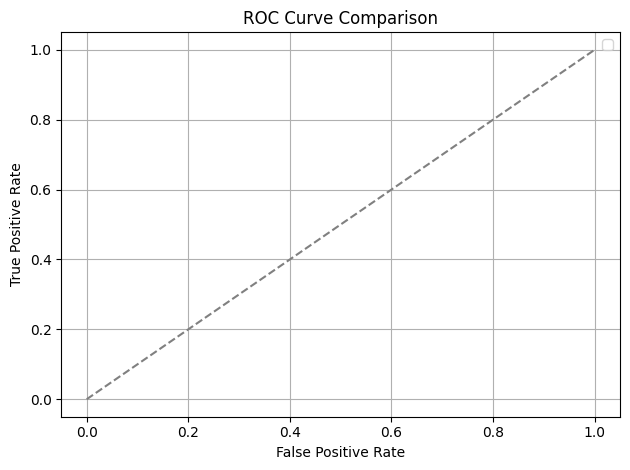

In [ ]:
models = [
    ("Random Forest (Untuned)", rf_preds, rf_probs),
    ("Random Forest (Tuned)", rf_best_preds, rf_best_probs),
    ("XGBoost", xgb_preds, xgb_probs),
]

compare_models(models, X_test, y_test)

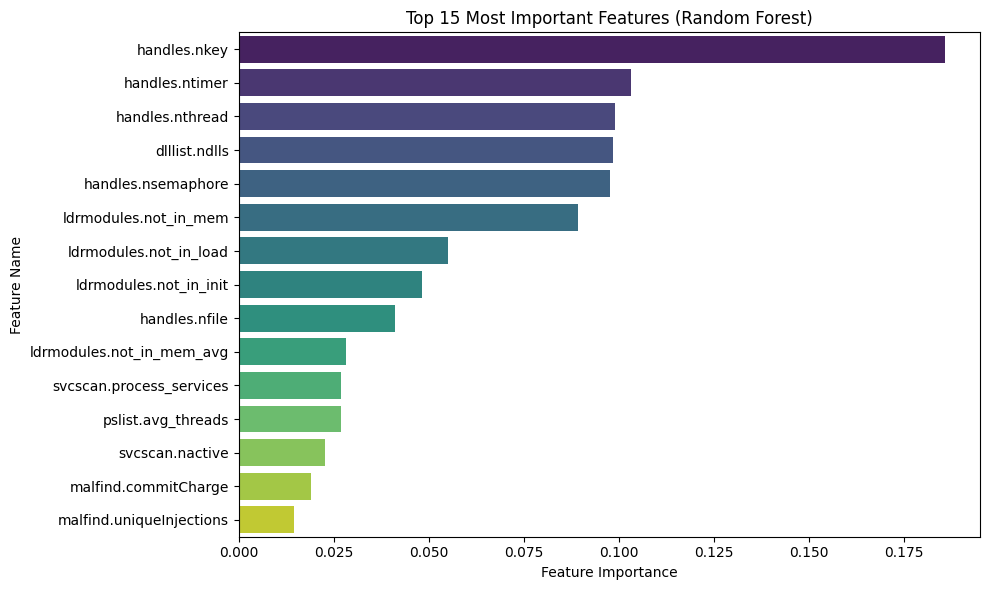

In [ ]:
# Get feature importances from the tuned Random Forest model
importances = best_rf.feature_importances_
feature_names = X_clean.columns

# Create a DataFrame for easy sorting and visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot top N features
top_n = 15
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df.head(top_n),
    palette='viridis'
)
plt.title(f'Top {top_n} Most Important Features (Random Forest)')
plt.xlabel('Feature Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_precision_recall_curve(y_test, probs_dict):
    plt.figure(figsize=(7, 5))
    for name, probs in probs_dict.items():
        precision, recall, _ = precision_recall_curve(y_test, probs)
        ap = average_precision_score(y_test, probs)
        plt.plot(recall, precision, label=f"{name} (AP = {ap:.4f})")

    plt.title("Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

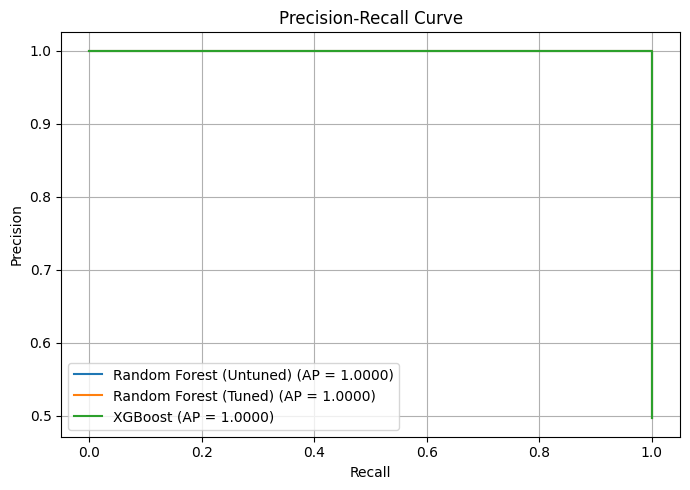

In [ ]:
probs_dict = {
    "Random Forest (Untuned)": rf_probs,
    "Random Forest (Tuned)": rf_best_probs,
    "XGBoost": xgb_probs,
}

plot_precision_recall_curve(y_test, probs_dict)